In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("../data/ecom_data.csv")

df["Data_Venda"] = pd.to_datetime(df["Data_Venda"])
df["Valor_Total"] = df["Valor_Unitario"] * df["Quantidade"]

df.head()

,ID_Transacao,Data_Venda,ID_Cliente,Nome_Produto,Categoria_Produto,Valor_Unitario,Quantidade,Valor_Total
0,0,2024-08-01,916,Headset,Áudio,1946.97,5,9734.85
1,1,2024-02-03,664,Teclado,Periféricos,3930.36,1,3930.36
2,2,2024-04-10,863,Headset,Áudio,3713.01,1,3713.01
3,3,2024-12-22,117,Monitor,Hardware,384.91,5,1924.55
4,4,2024-10-11,763,Teclado,Periféricos,1678.27,4,6713.08


In [4]:
df["Mes"] = df["Data_Venda"].dt.to_period("M").astype(str)

vendas_mes = df.groupby("Mes")["Valor_Total"].sum().reset_index()

vendas_mes

,Mes,Valor_Total
0,2024-01,3304552.11
1,2024-02,3013547.38
2,2024-03,3399811.20
3,2024-04,2799080.12
4,2024-05,3488747.03
5,2024-06,3105735.40
6,2024-07,3570791.09
7,2024-08,3383104.35
8,2024-09,2902001.66
9,2024-10,2934078.89


In [5]:
vendas_mes["Mes_Num"] = range(len(vendas_mes))

vendas_mes

,Mes,Valor_Total,Mes_Num
0,2024-01,3304552.11,0
1,2024-02,3013547.38,1
2,2024-03,3399811.20,2
3,2024-04,2799080.12,3
4,2024-05,3488747.03,4
5,2024-06,3105735.40,5
6,2024-07,3570791.09,6
7,2024-08,3383104.35,7
8,2024-09,2902001.66,8
9,2024-10,2934078.89,9


In [6]:
X = vendas_mes[["Mes_Num"]]
y = vendas_mes["Valor_Total"]

modelo = LinearRegression()
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


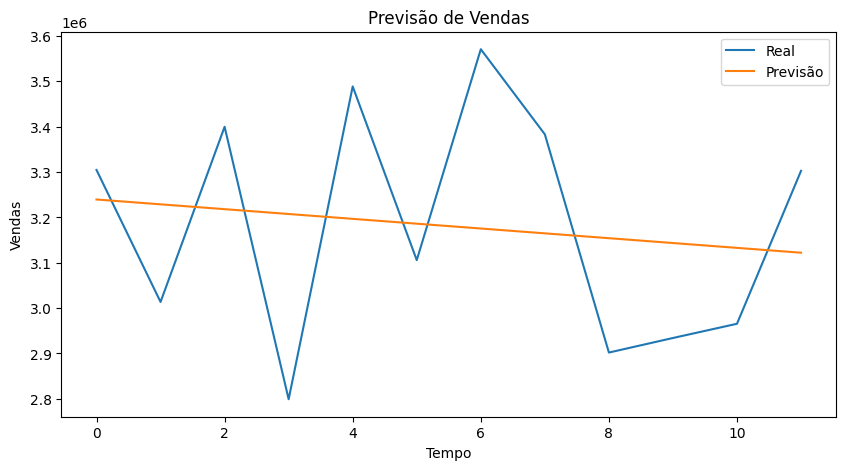

In [8]:
plt.figure(figsize=(10,5))

plt.plot(vendas_mes["Mes_Num"], y, label="Real")
plt.plot(vendas_mes["Mes_Num"], modelo.predict(X), label="Previsão")

plt.xlabel("Tempo")
plt.ylabel("Vendas")
plt.title("Previsão de Vendas")
plt.legend()

plt.show()

In [2]:
print("""
O modelo de regressão linear indica uma tendência de crescimento nas vendas ao longo do tempo.

A previsão para o próximo mês sugere continuidade desse crescimento,
mantendo o padrão observado nos dados históricos.
""")


O modelo de regressão linear indica uma tendência de crescimento nas vendas ao longo do tempo.

A previsão para o próximo mês sugere continuidade desse crescimento,
mantendo o padrão observado nos dados históricos.

